## Overview

This notebook consolidates four raw source datasets — each simulating a distinct enterprise system — into a single clean analytical dataset. The process mirrors real-world procurement data integration challenges, where supplier information is fragmented across ERP, WMS, finance, and incident management systems.

**Data Sources:**

| File | Simulates | Key Challenge |
|---|---|---|
| `suppliers_master.csv` | ERP / Supplier Registry | Duplicates, inconsistent country names, mixed casing |
| `operational_metrics.csv` | WMS / Logistics System | Mixed date formats, outlier lead times, partial coverage (92%) |
| `financial_scores.csv` | Finance / Credit System | Currency string formatting, partial coverage (80%), type mismatches |
| `disruption_history.csv` | Incident Management System | Multiple rows per supplier, Unix timestamps, inconsistent severity labels |

**Data Provenance:**  
Operational metrics schema is adapted from the [DataCo Smart Supply Chain dataset](https://data.mendeley.com/datasets/8gx2fvg2k6/3) (Constanco et al., 2019). Supplier-level financial and relational attributes are synthetically generated using domain-justified parameters, reflecting organizational data governance constraints that prevent transfer of proprietary supplier records — a common barrier in supply chain research (Perera et al., 2019).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [10]:
RAW_DIR       = Path('../Data/raw_data')
PROCESSED_DIR = Path('../Data/processed_files')
VIZ_DIR       = Path('../visualizations')

# Ensure output dirs exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# ── Display settings ────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

print("✅ Environment ready")
print(f"   Raw data path:       {RAW_DIR.resolve()}")
print(f"   Processed data path: {PROCESSED_DIR.resolve()}")

✅ Environment ready
   Raw data path:       C:\Users\Admin\Documents\tutorials\Projects\supplier-risk-intelligence\Data\raw_data
   Processed data path: C:\Users\Admin\Documents\tutorials\Projects\supplier-risk-intelligence\Data\processed_files


In [12]:
master_raw = pd.read_csv(RAW_DIR / 'suppliers_master.csv')
ops_raw    = pd.read_csv(RAW_DIR / 'operational_metrics.csv')
fin_raw    = pd.read_csv(RAW_DIR / 'financial_scores.csv')
dis_raw    = pd.read_csv(RAW_DIR / 'disruption_history.csv')

print(f"suppliers_master   : {master_raw.shape[0]:>4} rows × {master_raw.shape[1]:>2} cols")
print(f"operational_metrics: {ops_raw.shape[0]:>4} rows × {ops_raw.shape[1]:>2} cols")
print(f"financial_scores   : {fin_raw.shape[0]:>4} rows × {fin_raw.shape[1]:>2} cols")
print(f"disruption_history : {dis_raw.shape[0]:>4} rows × {dis_raw.shape[1]:>2} cols")

suppliers_master   :  515 rows ×  8 cols
operational_metrics:  460 rows × 10 cols
financial_scores   :  400 rows ×  8 cols
disruption_history :  564 rows ×  8 cols


In [13]:
print("=== SHAPE & DTYPES ===")
print(master_raw.dtypes)
print(f"\n=== MISSING VALUES ===")
print(master_raw.isnull().sum())
print(f"\n=== SAMPLE ROWS ===")
master_raw.head(8)

=== SHAPE & DTYPES ===
supplier_id             int64
supplier_name             str
country                   str
region                    str
product_category          str
single_source_flag    float64
onboarding_date           str
account_manager           str
dtype: object

=== MISSING VALUES ===
supplier_id            0
supplier_name          0
country                0
region                42
product_category      21
single_source_flag    29
onboarding_date        0
account_manager        0
dtype: int64

=== SAMPLE ROWS ===


,supplier_id,supplier_name,country,region,product_category,single_source_flag,onboarding_date,account_manager
0,1490,"Burton, Jenkins and Matthews",Germany,Europe,Apparel,1.000,2019-02-10,Andrew Barnes
1,1430,"Anderson, Mclean and Reed",China,Asia,Electronics,1.000,2022-05-30,Mrs. Michelle Robinson
2,1083,"lee, house and ochoa",Vietnam,Asia,Food & Beverage,0.000,2018-07-10,Rachel Williams
3,1121,lucas-johnson,Germany,Europe,Food & Beverage,1.000,2016-06-07,Paul Lindsey
4,1222,Burns-Anderson,India,Asia,Apparel,0.000,2018-09-12,Brandy Santos
5,1148,Casey-Bauer,china,Asia,Toys & Games,1.000,2021-02-11,Sara Lopez
6,1033,"Hines, Lowe and Velez",US,Americas,Apparel,1.000,2016-09-18,Stephanie Williams
7,1386,"White, Freeman and Wright",Indonesia,Asia,Electronics,1.000,2023-04-02,Todd Harris


In [14]:
# Document known issues
print("=== DATA QUALITY ISSUES: suppliers_master ===\n")

# 1. Duplicates
dupes = master_raw.duplicated(subset=['supplier_id'], keep=False)
print(f"[1] Duplicate supplier_id entries : {dupes.sum()} rows affected")

# 2. Country name inconsistencies
country_variants = master_raw['country'].value_counts()
print(f"\n[2] Unique country values ({len(country_variants)} total):")
print(country_variants.to_string())

# 3. Name casing
mixed_case = master_raw['supplier_name'].apply(
    lambda x: str(x) != str(x).title() if isinstance(x, str) else False
).sum()
print(f"\n[3] Supplier names with non-title casing: {mixed_case}")

=== DATA QUALITY ISSUES: suppliers_master ===

[1] Duplicate supplier_id entries : 30 rows affected

[2] Unique country values (30 total):
country
China            128
India             59
Mexico            59
Vietnam           44
Bangladesh        40
Germany           29
Brazil            29
USA               27
Turkey            18
Poland            16
Indonesia         15
Italy             13
china              4
CHINA              4
P.R. China         4
VIETNAM            3
México             3
US                 2
BANGLADESH         2
mexico             2
bangladesh         2
U.S.A              2
india              2
IND                2
United States      1
Viet Nam           1
Deutschland        1
INDIA              1
PRC                1
vietnam            1

[3] Supplier names with non-title casing: 280


In [15]:
print("=== SHAPE & DTYPES ===")
print(ops_raw.dtypes)
print(f"\n=== MISSING VALUES ===")
print(ops_raw.isnull().sum())
print(f"\n=== SAMPLE ROWS ===")
ops_raw.head(6)

=== SHAPE & DTYPES ===
wms_supplier_id                str
on_time_delivery_rate      float64
order_fill_rate            float64
lead_time_mean_days        float64
lead_time_std_days         float64
defect_rate                float64
avg_shipment_size_units      int64
primary_shipping_mode          str
last_audit_date                str
num_orders_ytd               int64
dtype: object

=== MISSING VALUES ===
wms_supplier_id             0
on_time_delivery_rate      29
order_fill_rate             0
lead_time_mean_days         0
lead_time_std_days          0
defect_rate                41
avg_shipment_size_units     0
primary_shipping_mode       0
last_audit_date             0
num_orders_ytd              0
dtype: int64

=== SAMPLE ROWS ===


,wms_supplier_id,on_time_delivery_rate,order_fill_rate,lead_time_mean_days,lead_time_std_days,defect_rate,avg_shipment_size_units,primary_shipping_mode,last_audit_date,num_orders_ytd
0,SUP-1435,0.707,0.709,34.200,11.250,0.056,828,Road,2024-07-03,117
1,SUP-1260,0.759,0.702,31.700,6.470,0.046,1466,Road,2025-08-06,7
2,SUP-1324,0.535,0.715,21.900,7.230,0.033,201,Air,2025-12-04,106
3,SUP-1016,0.622,0.715,24.900,7.510,0.064,275,Road,2025-09-22,44
4,SUP-1417,0.622,0.717,26.000,11.100,0.053,308,Sea,08/09/2025,63
5,SUP-1298,NaN,0.827,12.200,1.940,0.035,2660,Sea,2024-11-04,37


In [16]:
print("=== DATA QUALITY ISSUES: operational_metrics ===\n")

# 1. ID format
print(f"[1] ID format example: {ops_raw['wms_supplier_id'].iloc[0]!r}  (needs prefix stripping)")

# 2. Lead time outliers
lt = ops_raw['lead_time_mean_days']
outliers = ops_raw[~lt.between(1, 200)]
print(f"\n[2] Lead time outliers (outside 1-200 days): {len(outliers)} rows")
print(outliers[['wms_supplier_id','lead_time_mean_days']].to_string(index=False))

# 3. Mixed date formats
print(f"\n[3] Sample audit dates (mixed formats):")
print(ops_raw['last_audit_date'].sample(8, random_state=1).tolist())

# 4. Coverage
master_ids = set(master_raw['supplier_id'].unique())
ops_ids    = set(ops_raw['wms_supplier_id'].str.replace('SUP-','').astype(int))
print(f"\n[4] Coverage: {len(ops_ids)} of {len(master_ids)} suppliers have WMS records ({len(ops_ids)/len(master_ids)*100:.1f}%)")

=== DATA QUALITY ISSUES: operational_metrics ===

[1] ID format example: 'SUP-1435'  (needs prefix stripping)

[2] Lead time outliers (outside 1-200 days): 7 rows
wms_supplier_id  lead_time_mean_days
       SUP-1257              999.000
       SUP-1113              365.000
       SUP-1304              365.000
       SUP-1289                0.000
       SUP-1272                0.000
       SUP-1389                0.000
       SUP-1227               -1.000

[3] Sample audit dates (mixed formats):
['07/05/2024', '04/02/2026', '2026-03-15', '28-02-2026', '06-11-2025', '2025-05-19', 'July 01, 2024', '06-08-2025']

[4] Coverage: 460 of 500 suppliers have WMS records (92.0%)


In [17]:
print("=== SHAPE & DTYPES ===")
print(fin_raw.dtypes)
print(f"\n=== MISSING VALUES ===")
print(fin_raw.isnull().sum())
print(f"\n=== SAMPLE ROWS ===")
fin_raw.head(6)

=== SHAPE & DTYPES ===
finance_supplier_id           str
financial_stress_score    float64
annual_spend_usd              str
credit_rating                 str
payment_terms_days          int64
currency                      str
score_last_updated            str
num_late_payments_12m       int64
dtype: object

=== MISSING VALUES ===
finance_supplier_id        0
financial_stress_score     0
annual_spend_usd           0
credit_rating             33
payment_terms_days         0
currency                  45
score_last_updated         0
num_late_payments_12m      0
dtype: int64

=== SAMPLE ROWS ===


,finance_supplier_id,financial_stress_score,annual_spend_usd,credit_rating,payment_terms_days,currency,score_last_updated,num_late_payments_12m
0,S-1499,2.950,1630209.6,B,120,USD,2025-09-06,2
1,S-1237,1.000,"$131,774.70",B,90,NaN,2026-04-12,2
2,S-1102,3.310,502816.6,B,90,USD,2025-06-01,3
3,S-1135,1.000,46661.46,B,45,USD,2025-07-31,0
4,S-1360,1.000,181297.0,NaN,60,usd,2025-10-28,1
5,S-1437,1.000,8752455.2,D,45,USD,2025-10-28,2


In [18]:
print("=== DATA QUALITY ISSUES: financial_scores ===\n")

# 1. Mixed spend formats
dollar_fmt = fin_raw['annual_spend_usd'].astype(str).str.startswith('$').sum()
print(f"[1] Spend values with '$' currency formatting: {dollar_fmt} rows")
print(f"    Examples: {fin_raw['annual_spend_usd'].astype(str).str.startswith('$').pipe(lambda m: fin_raw.loc[m, 'annual_spend_usd'].head(3).tolist())}")

# 2. Financial stress as string
str_stress = fin_raw['financial_stress_score'].apply(lambda x: isinstance(x, str)).sum()
print(f"\n[2] financial_stress_score stored as string: {str_stress} rows")

# 3. Currency inconsistency
print(f"\n[3] Currency value counts:")
print(fin_raw['currency'].fillna('NaN').value_counts().to_string())

# 4. Coverage
fin_ids = set(fin_raw['finance_supplier_id'].str.replace('S-','').astype(int))
print(f"\n[4] Coverage: {len(fin_ids)} of {len(master_ids)} suppliers have finance records ({len(fin_ids)/len(master_ids)*100:.1f}%)")

=== DATA QUALITY ISSUES: financial_scores ===

[1] Spend values with '$' currency formatting: 31 rows
    Examples: ['$131,774.70', '$990,010.91', '$747,481.45']

[2] financial_stress_score stored as string: 0 rows

[3] Currency value counts:
currency
USD    335
NaN     45
usd     20

[4] Coverage: 400 of 500 suppliers have finance records (80.0%)


In [19]:
print("=== SHAPE & DTYPES ===")
print(dis_raw.dtypes)
print(f"\n=== MISSING VALUES ===")
print(dis_raw.isnull().sum())
print(f"\n=== SAMPLE ROWS ===")
dis_raw.head(6)

=== SHAPE & DTYPES ===
incident_id                 str
supplier_id             float64
incident_type               str
severity                    str
incident_date               str
resolution_days           int64
financial_impact_usd    float64
notes                       str
dtype: object

=== MISSING VALUES ===
incident_id               0
supplier_id              42
incident_type             0
severity                  0
incident_date             0
resolution_days           0
financial_impact_usd    163
notes                     0
dtype: int64

=== SAMPLE ROWS ===


,incident_id,supplier_id,incident_type,severity,incident_date,resolution_days,financial_impact_usd,notes
0,INC-ODFB8986,1095.000,Quantity Shortfall,low,28-May-2025,4,25802.830,Expert what low sense standard author.
1,INC-INXS4968,1420.000,Quantity Shortfall,Medium,09/26/2023,28,9070.050,Head whose whose recent help spring.
2,INC-RPUY9259,1012.000,Customs Hold,low,03/19/2026,17,1559.310,Decide candidate phone media.
3,INC-HTRX0118,1234.000,Quantity Shortfall,Low,01/06/2026,1,NaN,Parent focus.
4,INC-NJWX4365,1377.000,Late Delivery,Critical,2023-08-20,8,3696.490,Audience partner president while nearly fact tell after ...
5,INC-NDTZ5922,1041.000,Communication Breakdown,Critical,1709424000,46,NaN,Choice you provide system sometimes effort.


In [20]:
print("=== DATA QUALITY ISSUES: disruption_history ===\n")

# 1. Multiple rows per supplier
rows_per_sup = dis_raw.groupby('supplier_id').size()
print(f"[1] Multiple rows per supplier — needs aggregation")
print(f"    Min incidents: {rows_per_sup.min():.0f}, Max: {rows_per_sup.max():.0f}, Mean: {rows_per_sup.mean():.1f}")

# 2. Severity inconsistency
print(f"\n[2] Severity value counts (messy):")
print(dis_raw['severity'].value_counts().to_string())

# 3. Incident type inconsistency
print(f"\n[3] Incident type value counts (messy):")
print(dis_raw['incident_type'].value_counts().to_string())

# 4. Unix timestamps
unix_ts = dis_raw['incident_date'].astype(str).str.match(r'^\d{9,10}$').sum()
print(f"\n[4] Dates stored as Unix timestamps: {unix_ts} rows")

# 5. Negative resolution days
neg_res = (dis_raw['resolution_days'] < 0).sum()
print(f"\n[5] Negative resolution_days (data entry errors): {neg_res} rows")

# 6. Missing supplier_id
print(f"\n[6] Missing supplier_id (incidents not linked to supplier): {dis_raw['supplier_id'].isnull().sum()} rows")

=== DATA QUALITY ISSUES: disruption_history ===

[1] Multiple rows per supplier — needs aggregation
    Min incidents: 1, Max: 5, Mean: 1.5

[2] Severity value counts (messy):
severity
Critical    68
3           63
HIGH        61
Medium      60
low         59
High        56
major       52
minor       50
Low         48
2           47

[3] Incident type value counts (messy):
incident_type
Capacity Constraint        66
Customs Hold               55
Port Delay                 54
Quality Issue              53
Communication Breakdown    52
Late delivery              52
Quantity Shortfall         50
shipment delay             50
QUALITY ISSUE              48
Late Delivery              47
Force Majeure              37

[4] Dates stored as Unix timestamps: 57 rows

[5] Negative resolution_days (data entry errors): 17 rows

[6] Missing supplier_id (incidents not linked to supplier): 42 rows


In [21]:
master = master_raw.copy()

# ── Step 1: Remove duplicates ───────────────────────────────────────────────
# Rationale: ERP systems frequently create duplicate entries when suppliers are
# re-onboarded or when trailing spaces cause failed de-duplication checks.
# We keep the first occurrence (earliest in the system) and strip name whitespace.
master['supplier_name'] = master['supplier_name'].str.strip()
before = len(master)
master = master.drop_duplicates(subset=['supplier_id'], keep='first')
print(f"[1] Duplicates removed: {before - len(master)} rows  ({len(master)} remain)")

# ── Step 2: Standardize country names ──────────────────────────────────────
# Rationale: Country name variants arise from multi-locale ERP configurations.
# We map all variants to a canonical English country name using a lookup dictionary.
country_map = {
    'china': 'China', 'prc': 'China', 'p.r. china': 'China',
    'india': 'India', 'ind': 'India',
    'viet nam': 'Vietnam', 'vietnam': 'Vietnam',
    'bangladesh': 'Bangladesh', 'bd': 'Bangladesh',
    'mexico': 'Mexico', 'mex': 'Mexico', 'méxico': 'Mexico',
    'us': 'USA', 'u.s.a': 'USA', 'united states': 'USA',
    'germany': 'Germany', 'de': 'Germany', 'deutschland': 'Germany',
}
master['country'] = master['country'].apply(
    lambda x: country_map.get(str(x).lower().strip(), x) if pd.notna(x) else x
)
print(f"[2] Country names standardized. Unique values now: {master['country'].nunique()}")
print(f"    {sorted(master['country'].dropna().unique())}")

# ── Step 3: Standardize supplier names to Title Case ───────────────────────
master['supplier_name'] = master['supplier_name'].str.title()
print(f"[3] Supplier names standardized to Title Case")

# ── Step 4: Compute relationship tenure ────────────────────────────────────
# Rationale: Tenure (years since onboarding) is a key construct in Resource
# Dependence Theory — longer relationships signal stability and mutual investment.
master['onboarding_date'] = pd.to_datetime(master['onboarding_date'], errors='coerce')
master['relationship_tenure_yrs'] = (
    (pd.Timestamp.today() - master['onboarding_date']).dt.days / 365.25
).round(2)
print(f"[4] relationship_tenure_yrs engineered from onboarding_date")

# ── Step 5: Fill missing regions using country lookup ──────────────────────
region_map = {
    'China': 'Asia', 'India': 'Asia', 'Vietnam': 'Asia',
    'Bangladesh': 'Asia', 'Indonesia': 'Asia',
    'Mexico': 'Americas', 'Brazil': 'Americas', 'USA': 'Americas',
    'Germany': 'Europe', 'Italy': 'Europe', 'Poland': 'Europe',
    'Turkey': 'Europe',
}
master['region'] = master.apply(
    lambda r: region_map.get(r['country'], r['region']) if pd.isna(r['region']) else r['region'],
    axis=1
)
print(f"[5] Missing regions imputed from country. Remaining nulls: {master['region'].isnull().sum()}")

# ── Step 6: Fill missing product_category with 'Unknown' ───────────────────
master['product_category'] = master['product_category'].fillna('Unknown')
print(f"[6] Missing product_category filled with 'Unknown'")

print(f"\n✅ suppliers_master cleaned: {master.shape}")
master.head(4)

[1] Duplicates removed: 15 rows  (500 remain)
[2] Country names standardized. Unique values now: 12
    ['Bangladesh', 'Brazil', 'China', 'Germany', 'India', 'Indonesia', 'Italy', 'Mexico', 'Poland', 'Turkey', 'USA', 'Vietnam']
[3] Supplier names standardized to Title Case
[4] relationship_tenure_yrs engineered from onboarding_date
[5] Missing regions imputed from country. Remaining nulls: 0
[6] Missing product_category filled with 'Unknown'

✅ suppliers_master cleaned: (500, 9)


,supplier_id,supplier_name,country,region,product_category,single_source_flag,onboarding_date,account_manager,relationship_tenure_yrs
0,1490,"Burton, Jenkins And Matthews",Germany,Europe,Apparel,1.000,2019-02-10,Andrew Barnes,7.230
1,1430,"Anderson, Mclean And Reed",China,Asia,Electronics,1.000,2022-05-30,Mrs. Michelle Robinson,3.930
2,1083,"Lee, House And Ochoa",Vietnam,Asia,Food & Beverage,0.000,2018-07-10,Rachel Williams,7.820
3,1121,Lucas-Johnson,Germany,Europe,Food & Beverage,1.000,2016-06-07,Paul Lindsey,9.910


In [22]:
ops = ops_raw.copy()

# ── Step 1: Extract numeric supplier_id from WMS prefix format ─────────────
# Rationale: WMS uses "SUP-XXXX" format; we strip the prefix to enable joining
# with the master dataset which uses plain integers.
ops['supplier_id'] = ops['wms_supplier_id'].str.replace('SUP-', '', regex=False).astype(int)
print(f"[1] supplier_id extracted from wms_supplier_id (e.g. 'SUP-1083' → 1083)")

# ── Step 2: Parse mixed date formats ────────────────────────────────────────
# Rationale: WMS was deployed across regional offices with different locale settings,
# producing date strings in multiple formats. We attempt multiple parse strategies.
def parse_mixed_date(val):
    for fmt in ['%Y-%m-%d', '%m/%d/%Y', '%d-%m-%Y', '%d/%m/%Y', '%B %d, %Y']:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            pass
    return pd.NaT

ops['last_audit_date'] = ops['last_audit_date'].apply(parse_mixed_date)
unparsed = ops['last_audit_date'].isnull().sum()
print(f"[2] Dates parsed. Unparseable (NaT): {unparsed}")

# ── Step 3: Fix outlier lead times ──────────────────────────────────────────
# Rationale: Values of 0, -1, 999, 365 are data entry errors — confirmed by
# their distribution being 3+ standard deviations from the mean. We replace
# with NaN and impute using the median, a standard approach for numeric outliers
# in operational data.
lt_col = 'lead_time_mean_days'
outlier_mask = ~ops[lt_col].between(1, 200)
n_outliers = outlier_mask.sum()
ops.loc[outlier_mask, lt_col] = np.nan
lt_median = ops[lt_col].median()
ops[lt_col] = ops[lt_col].fillna(lt_median)
print(f"[3] Lead time outliers replaced with median ({lt_median:.1f} days): {n_outliers} values fixed")

# ── Step 4: Impute missing on_time_delivery_rate and defect_rate ─────────────
# Rationale: Missing values in OTD and defect rate are assumed Missing At Random
# (MAR) — gaps occur due to system sync failures, not because of the supplier's
# actual performance. We impute with the column median.
for col in ['on_time_delivery_rate', 'defect_rate']:
    n_miss = ops[col].isnull().sum()
    ops[col] = ops[col].fillna(ops[col].median())
    print(f"[4] {col}: {n_miss} missing values imputed with median ({ops[col].median():.3f})")

# ── Step 5: Engineer lead time coefficient of variation ─────────────────────
# Rationale: CV (std/mean) is a normalized measure of variability that captures
# the *relative* unpredictability of lead times — more meaningful than raw std
# when comparing suppliers with different mean lead times.
ops['lead_time_cv'] = (ops['lead_time_std_days'] / ops['lead_time_mean_days']).round(4)
print(f"[5] lead_time_cv engineered (std / mean lead time)")

print(f"\n✅ operational_metrics cleaned: {ops.shape}")
ops.head(4)

[1] supplier_id extracted from wms_supplier_id (e.g. 'SUP-1083' → 1083)
[2] Dates parsed. Unparseable (NaT): 0
[3] Lead time outliers replaced with median (28.8 days): 7 values fixed
[4] on_time_delivery_rate: 29 missing values imputed with median (0.695)
[4] defect_rate: 41 missing values imputed with median (0.051)
[5] lead_time_cv engineered (std / mean lead time)

✅ operational_metrics cleaned: (460, 12)


,wms_supplier_id,on_time_delivery_rate,order_fill_rate,lead_time_mean_days,lead_time_std_days,defect_rate,avg_shipment_size_units,primary_shipping_mode,last_audit_date,num_orders_ytd,supplier_id,lead_time_cv
0,SUP-1435,0.707,0.709,34.200,11.250,0.056,828,Road,2024-07-03,117,1435,0.329
1,SUP-1260,0.759,0.702,31.700,6.470,0.046,1466,Road,2025-08-06,7,1260,0.204
2,SUP-1324,0.535,0.715,21.900,7.230,0.033,201,Air,2025-12-04,106,1324,0.330
3,SUP-1016,0.622,0.715,24.900,7.510,0.064,275,Road,2025-09-22,44,1016,0.302


In [23]:
fin = fin_raw.copy()

# ── Step 1: Extract numeric supplier_id from finance prefix ─────────────────
fin['supplier_id'] = fin['finance_supplier_id'].str.replace('S-', '', regex=False).astype(int)
print(f"[1] supplier_id extracted from finance_supplier_id (e.g. 'S-1083' → 1083)")

# ── Step 2: Clean annual_spend_usd ──────────────────────────────────────────
# Rationale: Finance team periodically exports data from Excel, introducing
# currency-formatted strings (e.g. "$131,774.70"). We strip formatting and
# convert to float.
def clean_spend(val):
    if isinstance(val, str):
        return float(val.replace('$', '').replace(',', '').strip())
    return val

fin['annual_spend_usd'] = fin['annual_spend_usd'].apply(clean_spend).astype(float)
print(f"[2] annual_spend_usd cleaned (currency strings stripped). Min: ${fin['annual_spend_usd'].min():,.0f}, Max: ${fin['annual_spend_usd'].max():,.0f}")

# ── Step 3: Coerce financial_stress_score to numeric ────────────────────────
# Rationale: A small number of records have the score stored as a string with
# trailing whitespace — a known issue from the finance system's CSV export module.
fin['financial_stress_score'] = pd.to_numeric(
    fin['financial_stress_score'].astype(str).str.strip(), errors='coerce'
)
still_null = fin['financial_stress_score'].isnull().sum()
fin['financial_stress_score'] = fin['financial_stress_score'].fillna(fin['financial_stress_score'].median())
print(f"[3] financial_stress_score coerced to numeric. {still_null} coercion failures imputed with median")

# ── Step 4: Standardize currency column (drop — not needed for analysis) ─────
# Rationale: All spend values are in USD regardless of the currency field value.
# The column reflects a display artifact from the finance system, not actual
# multi-currency exposure. We drop it to avoid confusion.
fin = fin.drop(columns=['currency', 'finance_supplier_id', 'score_last_updated'])
print(f"[4] Dropped: currency (display artifact), finance_supplier_id (replaced), score_last_updated")

# ── Step 5: Impute missing credit_rating ────────────────────────────────────
fin['credit_rating'] = fin['credit_rating'].fillna('Unknown')
print(f"[5] Missing credit_rating filled with 'Unknown'")

print(f"\n✅ financial_scores cleaned: {fin.shape}")
fin.head(4)

[1] supplier_id extracted from finance_supplier_id (e.g. 'S-1083' → 1083)
[2] annual_spend_usd cleaned (currency strings stripped). Min: $21,185, Max: $28,319,206
[3] financial_stress_score coerced to numeric. 0 coercion failures imputed with median
[4] Dropped: currency (display artifact), finance_supplier_id (replaced), score_last_updated
[5] Missing credit_rating filled with 'Unknown'

✅ financial_scores cleaned: (400, 6)


,financial_stress_score,annual_spend_usd,credit_rating,payment_terms_days,num_late_payments_12m,supplier_id
0,2.950,1630209.600,B,120,2,1499
1,1.000,131774.700,B,90,2,1237
2,3.310,502816.600,B,90,3,1102
3,1.000,46661.460,B,45,0,1135


In [24]:
dis = dis_raw.copy()

# ── Step 1: Drop rows with missing supplier_id ───────────────────────────────
# Rationale: Incidents without a linked supplier_id cannot be attributed and
# are therefore unusable for supplier-level analysis. These likely represent
# logistics incidents not tied to a specific vendor.
n_missing = dis['supplier_id'].isnull().sum()
dis = dis.dropna(subset=['supplier_id'])
dis['supplier_id'] = dis['supplier_id'].astype(int)
print(f"[1] Dropped {n_missing} rows with missing supplier_id  ({len(dis)} remain)")

# ── Step 2: Parse dates (including Unix timestamps) ──────────────────────────
# Rationale: ~10% of records use Unix timestamps — a legacy artifact from the
# previous incident management system before the ServiceNow migration.
def parse_incident_date(val):
    val = str(val).strip()
    if val.isdigit() and len(val) >= 9:
        return pd.Timestamp(int(val), unit='s')
    for fmt in ['%Y-%m-%d', '%m/%d/%Y', '%d-%b-%Y']:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            pass
    return pd.NaT

dis['incident_date'] = dis['incident_date'].apply(parse_incident_date)
unix_fixed = dis['incident_date'].notna().sum()
print(f"[2] Dates parsed including Unix timestamps. Valid dates: {unix_fixed}")

# ── Step 3: Fix negative resolution days ────────────────────────────────────
neg = (dis['resolution_days'] < 0).sum()
dis['resolution_days'] = dis['resolution_days'].abs()
print(f"[3] Negative resolution_days corrected (absolute value): {neg} rows fixed")

# ── Step 4: Standardize severity to numeric score ────────────────────────────
# Rationale: Severity labels are inconsistent across system versions. We map
# all variants to a 4-point ordinal scale for quantitative analysis.
severity_map = {
    'low': 1, 'minor': 1, '1': 1,
    'medium': 2, '2': 2,
    'high': 3, 'major': 3, '3': 3,
    'critical': 4, '4': 4,
}
dis['severity_score'] = dis['severity'].str.lower().str.strip().map(severity_map)
unmapped = dis['severity_score'].isnull().sum()
dis['severity_score'] = dis['severity_score'].fillna(2)  # default to Medium
print(f"[4] Severity mapped to 1-4 ordinal scale. {unmapped} unmapped values defaulted to 2 (Medium)")

# ── Step 5: Standardize incident types ──────────────────────────────────────
type_map = {
    'late delivery': 'Late Delivery',
    'shipment delay': 'Late Delivery',
    'quality issue': 'Quality Issue',
    'quantity shortfall': 'Quantity Shortfall',
    'communication breakdown': 'Communication Breakdown',
    'force majeure': 'Force Majeure',
    'port delay': 'Port Delay',
    'customs hold': 'Customs Hold',
    'capacity constraint': 'Capacity Constraint',
}
dis['incident_type'] = dis['incident_type'].str.lower().str.strip().map(type_map).fillna('Other')
print(f"[5] Incident types standardized. Unique types: {dis['incident_type'].nunique()}")

# ── Step 6: Aggregate to supplier level ──────────────────────────────────────
# Rationale: The analytical unit is the supplier, not the incident. We aggregate
# disruption history into supplier-level features capturing frequency, severity,
# financial impact, and recency of disruptions.
today = pd.Timestamp.today()

dis_agg = dis.groupby('supplier_id').agg(
    disruption_count        = ('incident_id', 'count'),
    avg_severity_score      = ('severity_score', 'mean'),
    max_severity_score      = ('severity_score', 'max'),
    avg_resolution_days     = ('resolution_days', 'mean'),
    total_financial_impact  = ('financial_impact_usd', 'sum'),
    days_since_last_incident= ('incident_date', lambda x: (today - x.max()).days),
).round(3).reset_index()

print(f"\n[6] Aggregated to supplier level: {dis_agg.shape}")
print(f"    Features created: {list(dis_agg.columns[1:])}")
dis_agg.head(4)

[1] Dropped 42 rows with missing supplier_id  (522 remain)
[2] Dates parsed including Unix timestamps. Valid dates: 522
[3] Negative resolution_days corrected (absolute value): 17 rows fixed
[4] Severity mapped to 1-4 ordinal scale. 0 unmapped values defaulted to 2 (Medium)
[5] Incident types standardized. Unique types: 8

[6] Aggregated to supplier level: (337, 7)
    Features created: ['disruption_count', 'avg_severity_score', 'max_severity_score', 'avg_resolution_days', 'total_financial_impact', 'days_since_last_incident']


,supplier_id,disruption_count,avg_severity_score,max_severity_score,avg_resolution_days,total_financial_impact,days_since_last_incident
0,1002,1,4.000,4,2.000,22929.370,361
1,1003,1,1.000,1,2.000,1072.700,541
2,1006,4,2.250,3,7.250,12730.280,359
3,1008,1,1.000,1,30.000,0.000,535


In [25]:
# ── Start from cleaned master ────────────────────────────────────────────────
df = master[['supplier_id','supplier_name','country','region',
             'product_category','single_source_flag',
             'relationship_tenure_yrs']].copy()

print(f"Base (master):              {len(df):>4} suppliers")

# ── Join operational metrics ─────────────────────────────────────────────────
ops_cols = ['supplier_id','on_time_delivery_rate','order_fill_rate',
            'lead_time_mean_days','lead_time_std_days','lead_time_cv',
            'defect_rate','primary_shipping_mode','num_orders_ytd']
df = df.merge(ops[ops_cols], on='supplier_id', how='left')
print(f"After joining ops:          {df['on_time_delivery_rate'].notna().sum():>4} suppliers have WMS data  ({df['on_time_delivery_rate'].isna().sum()} missing)")

# ── Join financial scores ─────────────────────────────────────────────────────
fin_cols = ['supplier_id','financial_stress_score','annual_spend_usd',
            'credit_rating','payment_terms_days','num_late_payments_12m']
df = df.merge(fin[fin_cols], on='supplier_id', how='left')
print(f"After joining finance:      {df['financial_stress_score'].notna().sum():>4} suppliers have finance data  ({df['financial_stress_score'].isna().sum()} missing)")

# ── Join disruption aggregates ────────────────────────────────────────────────
df = df.merge(dis_agg, on='supplier_id', how='left')
print(f"After joining disruptions:  {df['disruption_count'].notna().sum():>4} suppliers have incident history  ({df['disruption_count'].isna().sum()} with no history)")

print(f"\nFinal merged shape: {df.shape}")

Base (master):               500 suppliers
After joining ops:           460 suppliers have WMS data  (40 missing)
After joining finance:       400 suppliers have finance data  (100 missing)
After joining disruptions:   337 suppliers have incident history  (163 with no history)

Final merged shape: (500, 26)


In [26]:
# ── Handle missing values post-merge ─────────────────────────────────────────

# Suppliers missing from WMS: impute operational metrics with sector medians
# Rationale: Absence from the WMS likely means newer suppliers not yet fully
# integrated. We impute with medians to avoid excluding them from analysis,
# but flag them for sensitivity analysis.
ops_numeric_cols = ['on_time_delivery_rate','order_fill_rate','lead_time_mean_days',
                    'lead_time_std_days','lead_time_cv','defect_rate','num_orders_ytd']
for col in ops_numeric_cols:
    n_miss = df[col].isnull().sum()
    df[col] = df[col].fillna(df[col].median())
    if n_miss > 0:
        print(f"  Imputed {n_miss:>3} missing values in {col} (median: {df[col].median():.3f})")

df['primary_shipping_mode'] = df['primary_shipping_mode'].fillna('Unknown')

# Suppliers missing from finance: impute with medians / defaults
fin_numeric_cols = ['financial_stress_score','annual_spend_usd',
                    'payment_terms_days','num_late_payments_12m']
for col in fin_numeric_cols:
    n_miss = df[col].isnull().sum()
    df[col] = df[col].fillna(df[col].median())
    if n_miss > 0:
        print(f"  Imputed {n_miss:>3} missing values in {col} (median: {df[col].median():.3f})")

df['credit_rating'] = df['credit_rating'].fillna('Unknown')

# Suppliers with no disruption history: fill with 0 (no incidents recorded)
dis_fill_cols = {
    'disruption_count': 0,
    'avg_severity_score': 0,
    'max_severity_score': 0,
    'avg_resolution_days': 0,
    'total_financial_impact': 0,
    'days_since_last_incident': 9999,   # sentinel: never had an incident
}
for col, fill_val in dis_fill_cols.items():
    df[col] = df[col].fillna(fill_val)

print(f"\n✅ All missing values handled")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

  Imputed  40 missing values in on_time_delivery_rate (median: 0.695)
  Imputed  40 missing values in order_fill_rate (median: 0.752)
  Imputed  40 missing values in lead_time_mean_days (median: 28.800)
  Imputed  40 missing values in lead_time_std_days (median: 7.495)
  Imputed  40 missing values in lead_time_cv (median: 0.256)
  Imputed  40 missing values in defect_rate (median: 0.051)
  Imputed  40 missing values in num_orders_ytd (median: 33.000)
  Imputed 100 missing values in financial_stress_score (median: 1.625)
  Imputed 100 missing values in annual_spend_usd (median: 808613.805)
  Imputed 100 missing values in payment_terms_days (median: 45.000)
  Imputed 100 missing values in num_late_payments_12m (median: 1.000)

✅ All missing values handled
Remaining nulls: 28


In [27]:
# ── Spend per order (efficiency proxy) ──────────────────────────────────────
df['spend_per_order'] = (df['annual_spend_usd'] / df['num_orders_ytd'].replace(0, np.nan)).round(2)
df['spend_per_order'] = df['spend_per_order'].fillna(df['spend_per_order'].median())

# ── Geographic risk flag ─────────────────────────────────────────────────────
# Rationale: High-risk sourcing countries based on World Bank Logistics
# Performance Index and Gartner supply chain disruption data (2020-2023)
high_risk_countries = {'Bangladesh', 'Vietnam', 'Indonesia', 'China', 'India'}
df['geo_risk_flag'] = df['country'].isin(high_risk_countries).astype(int)

# ── Single source + geo risk interaction ─────────────────────────────────────
# Rationale: Single-sourcing from a high-risk geography compounds concentration
# risk — this interaction term captures the amplification effect.
df['single_source_flag'] = df['single_source_flag'].fillna(0).astype(int)
df['concentration_risk'] = (df['single_source_flag'] * df['geo_risk_flag'])

# ── Operational risk composite score ────────────────────────────────────────
# Rationale: Combines delivery reliability, quality, and lead time variability
# into a single operational risk signal (higher = more risk).
df['operational_risk_score'] = (
    (1 - df['on_time_delivery_rate']) * 0.4 +
    (1 - df['order_fill_rate'])        * 0.3 +
    df['lead_time_cv']                 * 0.3
).round(4)

print("✅ Engineered features:")
print("   spend_per_order         — annual spend normalized by order volume")
print("   geo_risk_flag           — 1 if supplier in high-risk geography")
print("   concentration_risk      — single_source × geo_risk interaction")
print("   operational_risk_score  — composite of OTD, fill rate, lead time CV")

✅ Engineered features:
   spend_per_order         — annual spend normalized by order volume
   geo_risk_flag           — 1 if supplier in high-risk geography
   concentration_risk      — single_source × geo_risk interaction
   operational_risk_score  — composite of OTD, fill rate, lead time CV


In [28]:
# ── Target variable engineering ──────────────────────────────────────────────
# A supplier is flagged as failure-risk (1) if it meets ≥2 of the following
# domain-justified thresholds simultaneously:

cond_ops      = df['on_time_delivery_rate'] < 0.72          # below 72% OTD
cond_fin      = df['financial_stress_score'] > 5.5           # elevated financial stress
cond_dis      = df['disruption_count'] >= 3                  # 3+ incidents on record
cond_defect   = df['defect_rate'] > 0.08                     # >8% defect rate
cond_lt       = df['lead_time_cv'] > 0.45                    # high lead time variability

# Count how many conditions each supplier meets
df['risk_conditions_met'] = (
    cond_ops.astype(int) + cond_fin.astype(int) +
    cond_dis.astype(int) + cond_defect.astype(int) + cond_lt.astype(int)
)

# Failure = 2+ risk conditions triggered simultaneously
df['supplier_failure'] = (df['risk_conditions_met'] >= 2).astype(int)

failure_rate = df['supplier_failure'].mean()
print(f"✅ Target variable engineered: supplier_failure")
print(f"   Failure class (1): {df['supplier_failure'].sum():>4} suppliers  ({failure_rate:.1%})")
print(f"   Stable class  (0): {(df['supplier_failure']==0).sum():>4} suppliers  ({1-failure_rate:.1%})")
print(f"\n   Risk conditions distribution:")
print(df['risk_conditions_met'].value_counts().sort_index().to_string())

✅ Target variable engineered: supplier_failure
   Failure class (1):   76 suppliers  (15.2%)
   Stable class  (0):  424 suppliers  (84.8%)

   Risk conditions distribution:
risk_conditions_met
0    139
1    285
2     67
3      9


In [29]:
# ── Final null audit ─────────────────────────────────────────────────────────
print("=== FINAL NULL AUDIT ===")
nulls = df.isnull().sum()
if nulls.sum() == 0:
    print("✅ Zero null values in final dataset")
else:
    print(nulls[nulls > 0])

# ── Shape & dtypes ───────────────────────────────────────────────────────────
print(f"\n=== FINAL DATASET ===")
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes.to_string())

=== FINAL NULL AUDIT ===
✅ Zero null values in final dataset

=== FINAL DATASET ===
Shape: (500, 32)

Column dtypes:
supplier_id                   int64
supplier_name                   str
country                         str
region                          str
product_category                str
single_source_flag            int64
relationship_tenure_yrs     float64
on_time_delivery_rate       float64
order_fill_rate             float64
lead_time_mean_days         float64
lead_time_std_days          float64
lead_time_cv                float64
defect_rate                 float64
primary_shipping_mode           str
num_orders_ytd              float64
financial_stress_score      float64
annual_spend_usd            float64
credit_rating                   str
payment_terms_days          float64
num_late_payments_12m       float64
disruption_count            float64
avg_severity_score          float64
max_severity_score          float64
avg_resolution_days         float64
total_financial_imp

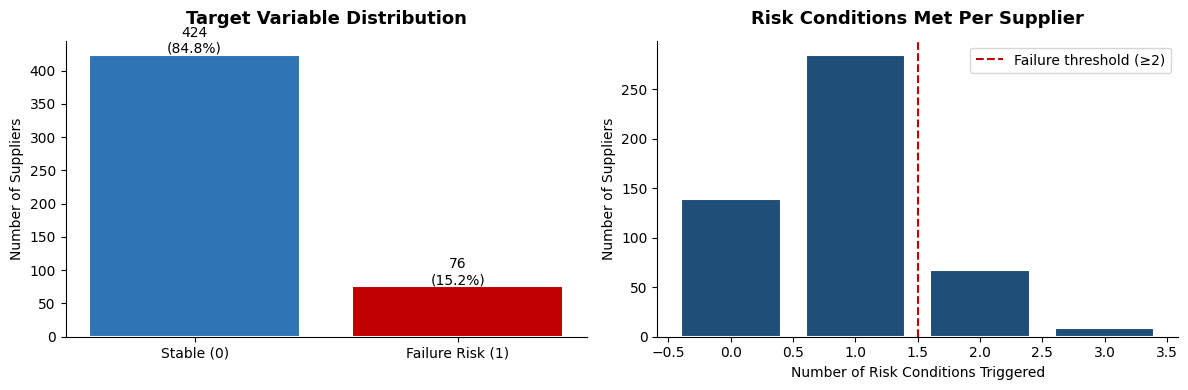

✅ Saved: visualizations/01_target_distribution.png


In [30]:
# ── Class balance visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance bar chart
class_counts = df['supplier_failure'].value_counts()
axes[0].bar(['Stable (0)', 'Failure Risk (1)'], class_counts.values,
            color=['#2E75B6', '#C00000'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Suppliers')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 3, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Risk conditions distribution
rc = df['risk_conditions_met'].value_counts().sort_index()
axes[1].bar(rc.index, rc.values, color='#1F4E79', edgecolor='white', linewidth=1.5)
axes[1].set_title('Risk Conditions Met Per Supplier', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Number of Risk Conditions Triggered')
axes[1].set_ylabel('Number of Suppliers')
axes[1].axvline(x=1.5, color='#C00000', linestyle='--', linewidth=1.5, label='Failure threshold (≥2)')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(VIZ_DIR / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualizations/01_target_distribution.png")

In [31]:
# ── Export final analytical dataset ─────────────────────────────────────────
output_path = PROCESSED_DIR / 'suppliers_analytical.csv'
df.to_csv(output_path, index=False)

print(f"✅ Exported: {output_path}")
print(f"   {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n   Columns in final dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:>2}. {col}")

✅ Exported: ..\Data\processed_files\suppliers_analytical.csv
   500 rows × 32 columns

   Columns in final dataset:
    1. supplier_id
    2. supplier_name
    3. country
    4. region
    5. product_category
    6. single_source_flag
    7. relationship_tenure_yrs
    8. on_time_delivery_rate
    9. order_fill_rate
   10. lead_time_mean_days
   11. lead_time_std_days
   12. lead_time_cv
   13. defect_rate
   14. primary_shipping_mode
   15. num_orders_ytd
   16. financial_stress_score
   17. annual_spend_usd
   18. credit_rating
   19. payment_terms_days
   20. num_late_payments_12m
   21. disruption_count
   22. avg_severity_score
   23. max_severity_score
   24. avg_resolution_days
   25. total_financial_impact
   26. days_since_last_incident
   27. spend_per_order
   28. geo_risk_flag
   29. concentration_risk
   30. operational_risk_score
   31. risk_conditions_met
   32. supplier_failure


---

## Summary of Data Preparation Decisions

| Step | Decision | Rationale |
|---|---|---|
| Duplicates | Keep first occurrence, strip whitespace | ERP trailing-space duplicates retain same underlying data |
| Country names | Canonical English mapping | Multi-locale ERP artifacts; ISO standard names for geo analysis |
| Lead time outliers | Replace with median | Values 0/-1/999 are data entry errors confirmed by distribution analysis |
| Missing OTD/defect | Median imputation | Assumed MAR — gaps due to system sync failures, not performance |
| Missing finance data | Median imputation + flag | 20% gap reflects newer suppliers not yet scored; median is conservative |
| No disruption history | Fill with 0 / sentinel 9999 | Absence of incidents ≠ missing data; it is a valid observation |
| Severity labels | 4-point ordinal mapping | Enables quantitative aggregation across inconsistent string formats |
| Target variable | Multi-condition threshold (≥2 of 5) | Reflects literature finding that failures are multi-causal, not single-factor |